In [2]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, MultipleLocator

import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import scipy.stats as stats


from tqdm import tqdm

import sys
sys.path.append('../')
from functions.data_processing.read_data import load_label, load_label2
from functions.utils import *

# Volume Relation with Impact Force

In [3]:
import json
with open("../config/event_id_map.json", "r") as f:
    event_id_map = json.load(f)

In [4]:
volume_df = pd.read_csv("../label/DF_Characteristics_2019-2023.csv", index_col=0)
volume_df.drop(1, inplace=True)
volume_df.reset_index(drop=True, inplace=True)
volume_df['Event_Date'] = volume_df['Event_Date'].apply(lambda x: UTCDateTime(x))
volume_df.dropna(axis=0, subset=['Volume'], inplace=True)
volume_df.tail()


,Event_Date,Year,Julday,Volume,Velocity,Duration,Density
36,2023-06-02T00:00:00.000000Z,2023,153,4873.0,1.73,NaN,1724
37,2023-06-10T00:00:00.000000Z,2023,161,18534.0,2.02,NaN,1787
38,2023-07-12T00:00:00.000000Z,2023,193,119088.0,15.46,NaN,1785
39,2023-07-13T00:00:00.000000Z,2023,194,301099.0,10.70,NaN,1342
40,2023-11-14T00:00:00.000000Z,2023,318,103808.0,8.28,NaN,1514


In [5]:
volume_df_2019 = volume_df[volume_df['Year'] == 2019]
volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]
volume_2019 = volume_df_2019['Volume'].to_list()
density_2019 = volume_df_2019['Density'].to_list()
print(volume_2019, density_2019)

volume_df_2020 = volume_df[volume_df['Year'] == 2020]
volume_2020 = []
density_2020 = []
for idx, row in volume_df_2020.iterrows():
    if row['Julday'] in [156, 160, 169, 181, 243]:
        volume_2020.append(row['Volume'])
        density_2020.append(row['Density'])

print(volume_2020, density_2020)

volume_df_2021 = volume_df[volume_df['Year'] == 2021]
volume_2021 = []
density_2021 = []
for idx, row in volume_df_2021.iterrows():
    if row['Julday'] in [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]:
        volume_2021.append(row['Volume'])
        density_2021.append(row['Density'])
print(volume_2021, density_2021)

volume_df_2022 = volume_df[volume_df['Year'] == 2022]
volume_2022 = []
density_2022 = []
for idx, row in volume_df_2022.iterrows():
    if row['Julday'] in [156, 185]:
        volume_2022.append(row['Volume'])
        density_2022.append(row['Density'])
print(volume_2022, density_2022)

volume_df_2023 = volume_df[volume_df['Year'] == 2023]
volume_2023 = []
density_2023 = []
for idx, row in volume_df_2023.iterrows():
    if row['Julday'] in [153, 161, 193]:
        volume_2023.append(row['Volume'])
        density_2023.append(row['Density'])
print(volume_2023, density_2023)

[2313.0, 83123.0, 73144.0, 4959.0, 9869.0, 29077.0, 70705.0, 21031.0] [1682, 1870, 1827, 1917, 2191, 2223, 2323, 2031]
[92424.0, 5872.0, 5053.0, 6612.0, 95823.0] [1773, 1495, 1862, 2066, 1777]
[17741.0, 18972.0, 18044.0, 6127.0, 6175.0, 114424.0, 76906.0, 50861.0, 80880.0, 38737.0, 8538.0] [1675, 1455, 1669, 1602, 1749, 1628, 1605, 1373, 1916, 1884, 1697]
[39498.0, 115963.0] [1690, 1140]
[4873.0, 18534.0, 119088.0] [1724, 1787, 1785]


/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_6822/3812474037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]


Text(0, 0.5, 'Volume (m³)')

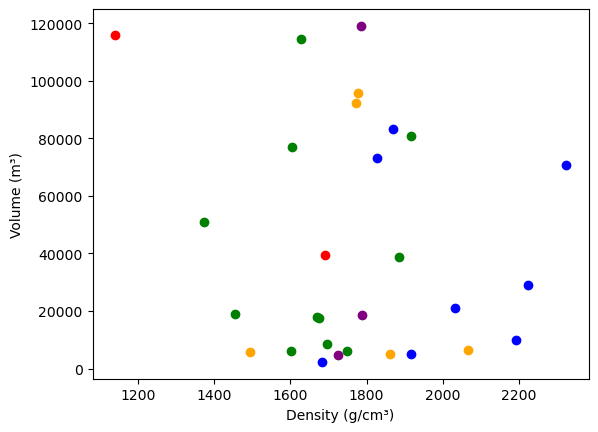

In [6]:
plt.scatter(density_2019, volume_2019, label='2019', color='blue')
plt.scatter(density_2020, volume_2020, label='2020', color='orange')
plt.scatter(density_2021, volume_2021, label='2021', color='green')
plt.scatter(density_2022, volume_2022, label='2022', color='red')
plt.scatter(density_2023, volume_2023, label='2023', color='purple')
plt.xlabel('Density (g/cm³)')
plt.ylabel('Volume (m³)')

In [7]:
# plt.figure(figsize=(6, 5))
# x_bins = np.linspace(0, 120_000, 10)
# y_bins = np.linspace(0, 9, 9)
# plt.hist2d(volume_df['Volume'], volume_df['Velocity'], bins=[x_bins, y_bins], cmap='viridis')
# plt.colorbar(label='Counts')
# plt.xlabel('Volume (m³)')
# plt.ylabel('Velocity (m/s)')
# plt.title('2D Histogram of Volume vs Velocity')
# plt.tight_layout()
# plt.show()

In [8]:
interval_seconds = 5
thres = 2

In [9]:
volume_2019 = []
csum_list = []
julday_list_2019 = []
for idx, row in tqdm(volume_df_2019.iterrows(), total=len(volume_df_2019)):
    if row['Event_ID'] == 5:
        continue
    event_info = event_id_map[str(row['Event_ID'])]
    label = load_label([str(row['Event_ID'])], "ILL11", interval_seconds, "average", True, 60, divide_by=None)
    label = label[label['Fv [kN]'] > thres]
    csum = label['Fv [kN]'].sum()
    csum_list.append(np.round(csum))
    volume_2019.append(row['Volume'])
    julday_list_2019.append(f"{row['Julday']}-{str(row['Year'])[-2:]}")

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:42<00:00,  5.37s/it]


In [10]:
csum_list, volume_2019

([4466.0, 14582.0, 11912.0, 3283.0, 9542.0, 12750.0, 5938.0],
 [2313.0, 83123.0, 73144.0, 9869.0, 29077.0, 70705.0, 21031.0])

In [ ]:
test_dir = "../model_test"
test_dir

In [ ]:
interval = interval_seconds
year = 2019
juldays = [161, 172, 182, 196, 207, 223, 232]
event_ids = ["1", "3", "4", "6", "7", "8", "9"]
results_2019 = {}
julday_list_2019 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
for model in ['xLSTM']:
    prediction_csums = []
    i = 0
    for julday, event_id in tqdm(zip(juldays, event_ids), total=len(juldays)):
        if julday in [182, 183]:
            df1 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday+1}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(event_id_map[event_id]['start_time']), UTCDateTime(event_id_map[event_id]['end_time']))]
        df.reset_index(drop=True, inplace=True)
        label = load_label([event_id], "ILL11", interval_seconds, "average", True, 60, divide_by=None)
        label['Timestamp'] = label['Timestamp'].apply(lambda x: UTCDateTime(x))
        combined = df.merge(label, how='left', left_on='Timestamps', right_on='Timestamp')
        combined.drop(columns=['Timestamp'], inplace=True)
        temp = combined[combined['Fv [kN]'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2019[model] = prediction_csums

100%|██████████| 7/7 [00:44<00:00,  6.30s/it]


In [ ]:
interval = interval_seconds
year = 2020
juldays = [156, 160, 169, 181, 243]
start_times = ["2020-06-04 15:00:00", "2020-06-08 15:00:00", "2020-06-17 03:00:00", "2020-06-29 04:30:00", "2020-08-30 05:00:00"] # "2020-06-07 09:00:00"
end_times = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"
julday_list_2020 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2020 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2020[model] = prediction_csums

100%|██████████| 5/5 [00:02<00:00,  1.68it/s]


In [ ]:
interval = interval_seconds
year = 2021
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 14:30:00", "2021-07-06 18:00:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]
julday_list_2021 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2021 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        if julday == 142:
            df1 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2021[model] = prediction_csums

100%|██████████| 11/11 [00:06<00:00,  1.66it/s]


In [ ]:
interval = interval_seconds
year = 2022
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
julday_list_2022 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2022 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2022[model] = prediction_csums

100%|██████████| 2/2 [00:01<00:00,  1.83it/s]


In [ ]:
interval = interval_seconds
year = 2023
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
end_times = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]
julday_list_2023 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2023 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2023[model] = prediction_csums

100%|██████████| 3/3 [00:01<00:00,  1.82it/s]


In [2]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5), sharey=True)

if interval_seconds == 5:
    xlim = 20_000
    xlim_major = 2_500
    xlim_minor = 500
elif interval_seconds == 15:
    xlim = 7_000 # 7_000
    xlim_major = 1_000 # 1_000
    xlim_minor = 250 # 250

# for axis in axes:
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(xlim_minor))
ax.xaxis.set_major_locator(MultipleLocator(xlim_major))
ax.yaxis.set_major_locator(MultipleLocator(20000))
ax.yaxis.set_minor_locator(MultipleLocator(5000))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, xlim + 1, xlim_major))
ax.set_yticks(range(0, 100_000 + 1, 20000))
ax.set_ylim(0, 100_000)
ax.set_xlim(0, xlim);
ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")


# scaled_csum = [csum_list[i] / density_2019[i] for i in range(len(csum_list))]
ax.plot(csum_list, volume_2019, 'ro')
for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
    ax.text(csum, vol+1000, julday, fontdict={"size": 8, "weight": "bold"})


# Regression Line
filt_csum, filt_vol = [], []
for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
    if julday in ["161-19", "172-19", "196-19", "207-19", "223-19", "232-19"]: # Data with new volumes
        filt_csum.append(csum)
        filt_vol.append(vol)


target_slope, target_intercept, _, _, _ = linregress(filt_csum, filt_vol)
print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept)


ax.set_xlim(0, xlim);
ax.set_ylim(0, 100_000);

y_val = 30_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
y_val = 80_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')


# for i, model in enumerate(['xLSTM', 'LSTM']):
model = 'xLSTM'
color = "green" 
ax.scatter(results_2019[model][:,0], volume_2019, color=color, marker="+", s=15, label=f"{model}")
ax.scatter(results_2019[model][:,1], volume_2019, color=color, marker="<", s=13)
ax.scatter(results_2019[model][:,2], volume_2019, color=color, marker=">", s=13)

ax.legend(loc="best", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
ax.text(0.01, 31_000/100_000, "30,000", transform=ax.transAxes, fontsize=8)
ax.text(0.01, 81_000/100_000, "80,000", transform=ax.transAxes, fontsize=8)
fig.tight_layout()
# fig.savefig(f"./output_images2/vol-force-selftest-thres{thres}_{interval_seconds}.png", dpi=300)

NameError: name 'plt' is not defined

In [22]:
r2 = r2_score(csum_list, volume_2019)
corr, _ = stats.pearsonr(csum_list, volume_2019)
print(f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}")

R2 Score: -105.92
Correlation: 0.96


In [23]:
volume_dict = {}
for jul, vol in zip(julday_list_2019, volume_2019):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2020, volume_2020):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2021, volume_2021):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2022, volume_2022):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2023, volume_2023):
    volume_dict[jul] = int(vol)

In [24]:
volume_dict

{'161-19': 2313,
 '172-19': 83123,
 '182-19': 73144,
 '196-19': 9869,
 '207-19': 29077,
 '223-19': 70705,
 '232-19': 21031,
 '156-20': 92424,
 '160-20': 5872,
 '169-20': 5053,
 '181-20': 6612,
 '243-20': 95823,
 '131-21': 17741,
 '136-21': 18972,
 '142-21': 18044,
 '156-21': 6127,
 '173-21': 6175,
 '175-21': 114424,
 '187-21': 76906,
 '194-21': 50861,
 '197-21': 80880,
 '219-21': 38737,
 '262-21': 8538,
 '156-22': 39498,
 '185-22': 115963,
 '153-23': 4873,
 '161-23': 18534,
 '193-23': 119088}

In [28]:
csum_list, volume_2019, julday_list_2019

([4466.0, 14582.0, 11912.0, 3283.0, 9542.0, 12750.0, 5938.0],
 [2313.0, 83123.0, 73144.0, 9869.0, 29077.0, 70705.0, 21031.0],
 ['161-19', '172-19', '182-19', '196-19', '207-19', '223-19', '232-19'])

Target Line of Best Fit: Slope = 13.8933, Intercept = -22518.5599
Target Line of Best Fit: Slope = 4.6311, Intercept = -22518.5599
Target Line of Best Fit: Slope = 6.9466, Intercept = -22518.5599


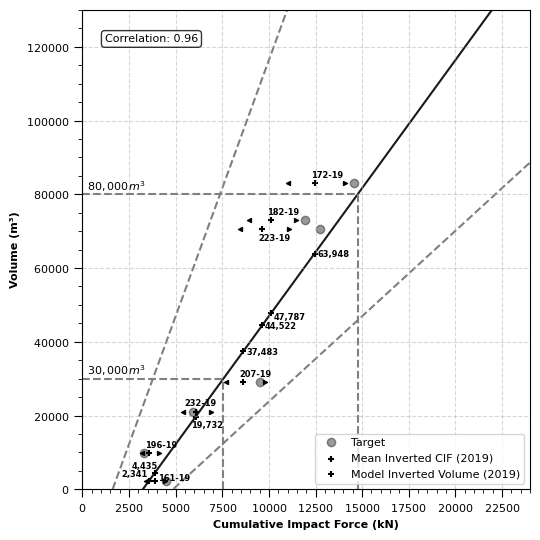

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(5.5,5.5))
if interval_seconds == 5:
    xlim = 24_000
    xlim_major = 2_500
    xlim_minor = 500
elif interval_seconds == 15:
    xlim = 8_000
    xlim_major = 1_000
    xlim_minor = 250

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(xlim_minor))
ax.xaxis.set_major_locator(MultipleLocator(xlim_major))
ax.yaxis.set_major_locator(MultipleLocator(20_000))
ax.yaxis.set_minor_locator(MultipleLocator(5_000))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, xlim+1, xlim_major))
ax.set_yticks(range(0, 130_000+1, 20_000))
ax.set_xlim(0, xlim);
ax.set_ylim(0, 130_000)
ax.plot(csum_list, volume_2019, 'ko', label = "Target", alpha = 0.4, zorder=0)
ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

# Regression Line
csum_list_2, volume_2019_2 = [], []
for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
    if julday in ["161-19", "172-19", "196-19", "207-19", "223-19", "232-19"]: # Data with new volumes
        csum_list_2.append(csum)
        volume_2019_2.append(vol)
csum_list_2 = np.array(csum_list_2)
volume_2019_2 = np.array(volume_2019_2)
lower_csum_list = csum_list_2 - csum_list_2 * 0.50
upper_csum_list = csum_list_2 + csum_list_2 * 0.50

target_slope_l, target_intercept_l, _, _, _ = linregress(lower_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_l:.4f}, Intercept = {target_intercept_l:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_l * plot_x + target_intercept_l, alpha=0.5, linestyle="--", color="k", zorder=0)

target_slope_u, target_intercept_u, _, _, _ = linregress(upper_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_u:.4f}, Intercept = {target_intercept_u:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_u * plot_x + target_intercept_u, alpha=0.5, linestyle="--", color="k", zorder=0)
    
target_slope, target_intercept, _, _, _ = linregress(csum_list_2, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, alpha=0.9, linestyle="-", color="k", zorder=0)

# xLSTM Predictions
# 2019
ax.scatter(results_2019['xLSTM'][:,0], volume_2019, color='black', marker="+", s=14, label = "Mean Inverted CIF (2019)", zorder=1)
ax.scatter(results_2019['xLSTM'][:,1], volume_2019, color='black', marker="<", s=8, zorder=0)
ax.scatter(results_2019['xLSTM'][:,2], volume_2019, color='black', marker=">", s=8, zorder=0)
## Label volume estimate 2019
csum_estimate_2019 = []
for i, csum in enumerate(results_2019['xLSTM'][:,0]):
    if i in []:
        vol_est = target_slope_l * csum + target_intercept_l
    elif i in []:
        vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2019.append(vol_est)
    if i in [2]:
        ax.text(csum+150, vol_est-2000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
    elif i in [0]:
        ax.text(csum-1250, vol_est+1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
    elif i in [3]:
        ax.text(csum-1500, vol_est+1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
    elif i in [6]:
        ax.text(csum-250, vol_est-3000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
    else:
        ax.text(csum+150, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.scatter(results_2019['xLSTM'][:,0], csum_estimate_2019, facecolor='black', marker="+", s=14, label="Model Inverted Volume (2019)")
for csum, vol, julday in zip(results_2019['xLSTM'][:,0], volume_2019, julday_list_2019):
    if julday == "161-19":
        ax.text(csum+150, vol, julday, fontdict={"size": 6, "weight": "bold"})
    elif julday == "232-19":
        ax.text(csum-600, vol+1500, julday, fontdict={"size": 6, "weight": "bold"})
    elif julday == "223-19":
        ax.text(csum-200, vol-3500, julday, fontdict={"size": 6, "weight": "bold"})
    else:
        ax.text(csum-200, vol+1300, julday, fontdict={"size": 6, "weight": "bold"})

ax.legend(loc="best", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
ax.text(0.01, 31_000/130_000, r"$30,000m^3$", transform=ax.transAxes, fontsize=8)
ax.text(0.01, 81_000/130_000, r"$80,000m^3$", transform=ax.transAxes, fontsize=8)
y_val = 30_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
y_val = 80_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

corr, _ = stats.pearsonr(csum_list, volume_2019)
info_text = f"Correlation: {corr:.2f}"
ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=8,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax.text(0.05, 0.9, "(a)", transform=ax.transAxes, fontsize=10, fontweight="bold", va='top', ha='left')

fig.tight_layout()
fig.savefig(f"./output_images4/Volume-CIF_{interval}sec_2019.png", dpi=600)
# plt.close(fig=fig)

Target Line of Best Fit: Slope = 13.8933, Intercept = -22518.5599
Target Line of Best Fit: Slope = 4.6311, Intercept = -22518.5599
Target Line of Best Fit: Slope = 6.9466, Intercept = -22518.5599


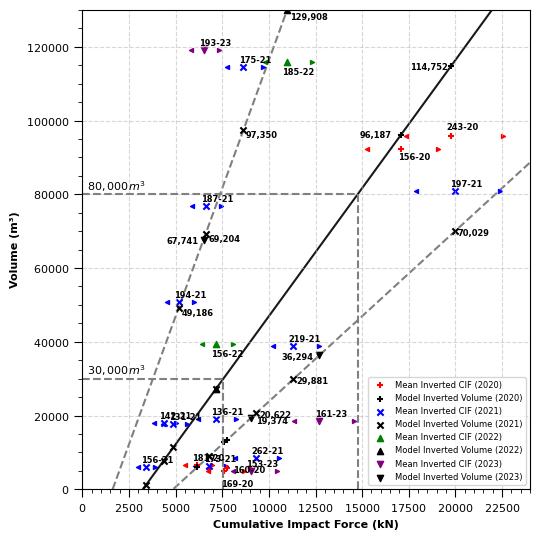

In [50]:
######################################################################################
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(5.5,5.5))
if interval_seconds == 5:
    xlim = 24_000
    xlim_major = 2_500
    xlim_minor = 500
elif interval_seconds == 15:
    xlim = 8_000
    xlim_major = 1_000
    xlim_minor = 250

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(xlim_minor))
ax.xaxis.set_major_locator(MultipleLocator(xlim_major))
ax.yaxis.set_major_locator(MultipleLocator(20_000))
ax.yaxis.set_minor_locator(MultipleLocator(5_000))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, xlim+1, xlim_major))
ax.set_yticks(range(0, 130_000+1, 20_000))
ax.set_xlim(0, xlim);
ax.set_ylim(0, 130_000)
ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

csum_list_2, volume_2019_2 = [], []
for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
    if julday in ["161-19", "172-19", "196-19", "207-19", "223-19", "232-19"]: # Data with new volumes
        csum_list_2.append(csum)
        volume_2019_2.append(vol)
csum_list_2 = np.array(csum_list_2)
volume_2019_2 = np.array(volume_2019_2)
lower_csum_list = csum_list_2 - csum_list_2 * 0.50
upper_csum_list = csum_list_2 + csum_list_2 * 0.50

target_slope_l, target_intercept_l, _, _, _ = linregress(lower_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_l:.4f}, Intercept = {target_intercept_l:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_l * plot_x + target_intercept_l, alpha=0.5, linestyle="--", color="k", zorder=0)

target_slope_u, target_intercept_u, _, _, _ = linregress(upper_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_u:.4f}, Intercept = {target_intercept_u:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_u * plot_x + target_intercept_u, alpha=0.5, linestyle="--", color="k", zorder=0)
    
target_slope, target_intercept, _, _, _ = linregress(csum_list_2, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, alpha=0.9, linestyle="-", color="k", zorder=0)

# 2020
ax.scatter(results_2020['xLSTM'][:,0], volume_2020, color='red', marker="+", s=20, label = "Mean Inverted CIF (2020)", zorder=1)
ax.scatter(results_2020['xLSTM'][:,1], volume_2020, color='red', marker="<", s=8, zorder=0)
ax.scatter(results_2020['xLSTM'][:,2], volume_2020, color='red', marker=">", s=8, zorder=0)
csum_estimate_2020 = []
for i, csum in enumerate(results_2020['xLSTM'][:,0]):
    if i in [1, 2, 3]:
        vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2020.append(vol_est)
    if vol_est < 30_000:
        pass
    else:
        if i in [0, 4]:
            ax.text(csum-2200, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
        elif i in [1]:
            ax.text(csum-750, vol_est, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")  
        elif i in [3]:
            ax.text(csum-750, vol_est, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")  
        else:
            ax.text(csum+150, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.scatter(results_2020['xLSTM'][:,0], csum_estimate_2020, facecolor='black', marker="+", s=20, label="Model Inverted Volume (2020)")
for csum, vol, julday in zip(results_2020['xLSTM'][:,0], volume_2020, julday_list_2020):
    if julday == "156-20":
        ax.text(csum-150, vol-3000, julday, fontdict={"size": 6, "weight": "bold"}) 
    elif julday == '169-20':
        ax.text(csum-150, vol-4500, julday, fontdict={"size": 6, "weight": "bold"}) 
    elif julday == '160-20':
        ax.text(csum+350, vol-1500, julday, fontdict={"size": 6, "weight": "bold"}) 
    elif julday == "243-20":
        ax.text(csum-250, vol+1500, julday, fontdict={"size": 6, "weight": "bold"}) 
    else:
        ax.text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

# # 2021
ax.scatter(results_2021['xLSTM'][:,0], volume_2021, color='blue', marker="x", s=20, label = "Mean Inverted CIF (2021)", zorder=1)
ax.scatter(results_2021['xLSTM'][:,1], volume_2021, color='blue', marker="<", s=8, zorder=0)
ax.scatter(results_2021['xLSTM'][:,2], volume_2021, color='blue', marker=">", s=8, zorder=0)
csum_estimate_2021 = []
for i, csum in enumerate(results_2021['xLSTM'][:,0]):
    if i in [5, 6, 7]:
        vol_est = target_slope_l * csum + target_intercept_l
    elif i in [4, 8, 9, 10]:
        vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2021.append(vol_est)
    if (vol_est < 30_000) & (csum < 7_500):
        pass
    else:
        if i in [2, 3, 4, 5, 6, 7]:
            ax.text(csum+150, vol_est-2200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
        else:
            ax.text(csum+150, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.scatter(results_2021['xLSTM'][:,0], csum_estimate_2021, facecolor='black', marker="x", s=20, label="Model Inverted Volume (2021)")
for csum, vol, julday in zip(results_2021['xLSTM'][:,0], volume_2021, julday_list_2021):
    ax.text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

# # 2022
ax.scatter(results_2022['xLSTM'][:,0], volume_2022, color='green', marker="^", s=20, label = "Mean Inverted CIF (2022)", zorder=1)
ax.scatter(results_2022['xLSTM'][:,1], volume_2022, color='green', marker="<", s=8, zorder=0)
ax.scatter(results_2022['xLSTM'][:,2], volume_2022, color='green', marker=">", s=8, zorder=0)
csum_estimate_2022 = []
for i, csum in enumerate(results_2022['xLSTM'][:,0]):
    if i in [1]:
        vol_est = target_slope_l * csum + target_intercept_l
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2022.append(vol_est)
    if vol_est < 30_000:
        pass
    else:
        ax.text(csum+150, vol_est-2500, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.scatter(results_2022['xLSTM'][:,0], csum_estimate_2022, color='black', marker="^", s=20, label="Model Inverted Volume (2022)", zorder=0)
for csum, vol, julday in zip(results_2022['xLSTM'][:,0], volume_2022, julday_list_2022):
    ax.text(csum-250, vol-3500, julday, fontdict={"size": 6, "weight": "bold"})

# # # 2023
ax.scatter(results_2023['xLSTM'][:,0], volume_2023, color='purple', marker="v", s=20, label = "Mean Inverted CIF (2023)", zorder=1)
ax.scatter(results_2023['xLSTM'][:,1], volume_2023, color='purple', marker="<", s=8, zorder=0)
ax.scatter(results_2023['xLSTM'][:,2], volume_2023, color='purple', marker=">", s=8, zorder=0)
csum_estimate_2023 = []
for i, csum in enumerate(results_2023['xLSTM'][:,0]):
    if i in [0, 1]:
        vol_est = vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = vol_est = target_slope_l * csum + target_intercept_l
    csum_estimate_2023.append(vol_est)
    if i in [0]:
        ax.text(csum+250, vol_est-1750, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
    else:
        ax.text(csum-2000, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.scatter(results_2023['xLSTM'][:,0], csum_estimate_2023, color='black', marker="v", s=20, label="Model Inverted Volume (2023)", zorder=0)
for csum, vol, julday in zip(results_2023['xLSTM'][:,0], volume_2023, julday_list_2023):
    ax.text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})


ax.legend(loc="lower right", fontsize=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.text(0.01, 31_000/130_000, r"$30,000m^3$", transform=ax.transAxes, fontsize=8)
ax.text(0.01, 81_000/130_000, r"$80,000m^3$", transform=ax.transAxes, fontsize=8)
y_val = 30_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
y_val = 80_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

# ax.text(0.05, 0.9, "(b)", transform=ax.transAxes, fontsize=10, fontweight="bold", va='top', ha='left')

fig.tight_layout()
fig.savefig(f"./output_images4/Volume-CIF_{interval}sec_2020-23.png", dpi=600)
# plt.close(fig=fig)
plt.show()


In [51]:
results_df = pd.DataFrame(columns=["Year", "Julian-Day", "Volume", "Estimated Volume Lower", "Estimated Volume", "Estimated Volume Upper", "CIF", "CIF_Lower", "CIF_Upper"])
year = 2019
for i, (julday, vol) in enumerate(zip(julday_list_2019, volume_2019)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2019['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [183, 207]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in []:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2020
for i, (julday, vol) in enumerate(zip(julday_list_2020, volume_2020)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2020['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [160, 169, 181]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in []:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2021
for i, (julday, vol) in enumerate(zip(julday_list_2021, volume_2021)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2021['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [173, 197, 219, 262]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in [156, 175, 187, 194]:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2022
for i, (julday, vol) in enumerate(zip(julday_list_2022, volume_2022)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2022['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in []:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in [185]:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2023
for i, (julday, vol) in enumerate(zip(julday_list_2023, volume_2023)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2023['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [153, 161]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in [193]:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]


In [52]:
results_df["Uncertainty_Lower"] = np.round((results_df['Estimated Volume'] - results_df['Estimated Volume Lower']) * 100 / results_df['Estimated Volume'],2)
results_df["Uncertainty_Upper"] = np.round((results_df['Estimated Volume Upper'] - results_df['Estimated Volume']) * 100 / results_df['Estimated Volume'],2)
results_df["Estimated"] = ["Yes" if j < i < k else "No" for idx, (i,j,k) in results_df.loc[:, ['Volume', "Estimated Volume Lower", "Estimated Volume Upper"]].iterrows()]
results_df["Absolute_Error"] = [np.round(np.abs(i - j)) for idx, (i,j) in results_df.loc[:, ['Volume', "Estimated Volume"]].iterrows()]
results_df['Percent_Error'] = np.round(results_df['Absolute_Error'] / results_df['Volume'], 4) * 100

In [58]:
results_df.to_csv(f"./output_images4/vol_estimates_{interval}secs.csv")

In [59]:
results_df

,Year,Julian-Day,Volume,Estimated Volume Lower,Estimated Volume,Estimated Volume Upper,CIF,CIF_Lower,CIF_Upper,Uncertainty_Lower,Uncertainty_Upper,Estimated,Absolute_Error,Percent_Error
0,2019.0,161.0,2313.0,1086.0,4434.0,8158.0,3880.0,3398.0,4416.0,75.51,83.99,Yes,2121.0,91.70
1,2019.0,172.0,83123.0,53895.0,63946.0,75151.0,12447.0,11000.0,14060.0,15.72,17.52,No,19177.0,23.07
2,2019.0,182.0,73144.0,39446.0,47788.0,56909.0,10121.0,8920.0,11434.0,17.46,19.09,No,25356.0,34.67
3,2019.0,196.0,9869.0,-192.0,2343.0,5893.0,3579.0,3214.0,4090.0,108.19,151.52,No,7526.0,76.26
4,2019.0,207.0,29077.0,13243.0,17480.0,22926.0,8637.0,7722.0,9813.0,24.24,31.16,No,11597.0,39.88
5,2019.0,223.0,70705.0,36320.0,44524.0,54353.0,9651.0,8470.0,11066.0,18.43,22.08,No,26181.0,37.03
6,2019.0,232.0,21031.0,15056.0,19731.0,25379.0,6082.0,5409.0,6895.0,23.69,28.63,Yes,1300.0,6.18
7,2020.0,156.0,92424.0,83591.0,96186.0,110058.0,17088.0,15275.0,19085.0,13.09,14.42,Yes,3762.0,4.07
8,2020.0,160.0,5872.0,8718.0,13377.0,19106.0,7751.0,6745.0,8988.0,34.83,42.83,No,7505.0,127.81
9,2020.0,169.0,5053.0,8589.0,12724.0,17698.0,7610.0,6717.0,8684.0,32.50,39.09,No,7671.0,151.81


In [68]:
results_df[results_df["Volume"]>10_000]['Percent_Error'].agg(['mean', 'std'])

mean    28.862632
std     22.353684
Name: Percent_Error, dtype: float64

In [55]:
from collections import Counter
Counter(results_df['Estimated'])

Counter({'No': 19, 'Yes': 9})

In [56]:
len(results_df[results_df['Percent_Error'] < 30]) / 28

0.39285714285714285

In [57]:
temp = results_df[results_df['Volume'] > 10000]
print(len(temp[temp['Percent_Error'] < 30]))
print(Counter(temp['Estimated']))

10
Counter({'No': 13, 'Yes': 6})


# Looking into seismic signatures

In [71]:
from obspy import Stream, Trace, UTCDateTime
from obspy.signal.filter import envelope

from functions.data_processing.read_data import load_label, load_label2, load_seismic_data_test

In [72]:
year = 2019
juldays_2019 = [161, 172, 182, 183, 196, 207, 223, 232]
event_ids_2019 = ["1", "3", "4", "5", "6", "7", "8", "9"]

year = 2020
juldays_2020 = [156, 160, 169, 181, 243] # 159
start_times_2020 = ["2020-06-04 15:30:00", "2020-06-08 17:30:00", "2020-06-17 04:30:00", "2020-06-29 05:00:00", "2020-08-30 05:45:00"] # "2020-06-07 09:00:00"
end_times_2020 = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"

year = 2021
juldays_2021 = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times_2021 = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 15:00:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:30:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times_2021 = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]

year = 2022
juldays_2022 = [156, 185]
start_times_2022 = ["2022-06-05 11:15:00", "2022-07-04 21:40:00"]
end_times_2022 = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]

year = 2023
juldays_2023 = [153, 161, 193]
start_times_2023 = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:30:00"]
end_times_2023 = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]